This is the sample code for the paper SLoG-Net: Algorithm Unrolling for Source Localization on Graphs.
The update version can be found in https://github.com/Yechang618.

Author: Chang Ye, cye7@ur.rochester.edu



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r drive/MyDrive/slog-net/SLoGexample .

Libraries and random seed

In [ ]:
import numpy as np
from numpy import linalg as LA
import torch; torch.set_default_dtype(torch.float64)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import pickle
import datetime
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
#### Import SLOG packakes
from SLoGexample import SLOGexperiment as SLOGexperiment
from SLoGexample import SLOGtools as SLOGtools
from SLoGexample import SLOGdata as SLOGdata
import torch
import os

useGPU = True
if useGPU and torch.cuda.is_available():
    device = 'cuda:0'
    torch.cuda.empty_cache()
else:
    device = 'cpu'
# Notify:
device = torch.device(device)
print("Device selected: %s" % device)
torch.manual_seed(0)
import random
random.seed(0)

Device selected: cpu


Experiment settings

In [ ]:
### Model parameters
K = 5 # number of layers


### Simulation parameters
simuParas = {}
P = 200
nTrain = P*500
batchsize, nValid, nTest = P, P, P
nEpochs, early_stop_criteria = 30, 1e-5
### Data parameters
L, alpha = 5, 1.0
### Graph parameters
nNodes = 20 # Number of nodes
S = int(0.15*nNodes) # Number of sources per signal
C = nNodes # constrain constant
q = 2 # Number of constrain vectors for SLOG-Net-v3


graphType = 'ER' # Type of graph
graphOptions = {} # Dictionary of options to pass to the graphTools.createGraph function
graphOptions['probIntra'] = 0.3 # Probability of drawing edges


## Filter type: g or h
filterType = 'h'
filterTrainType = 'h'
## Signal mode: gaussion or 1
signalMode = 'Gaussion'
## Train mode: Wt or default (Vdiag(\tilde{h})V^T)
trainMode = 'default'
## Filter mode: Wt or default (Vdiag(\tilde{h})V^T)
filterMode = 'default'
## Selection mode: random or nodes with top-N_C degree
selectMode = 'random'

## Noise level
noiseLevel = 0.0
noiseType = 'uniform'

simuParas = {'nNodes': nNodes,
        'S': S,
        'nTrain': nTrain,
        'batchsize': batchsize,
        'nValid': nValid,
        'nTest': nTest,
        'L': L,
        'noiseLevel': noiseLevel,
        'noiseType': noiseType,
        'filterType': filterType,
        'signalMode': signalMode,
        'trainMode': trainMode,
        'filterMode': filterMode,
        'selectMode': selectMode,
        'graphType': graphType,
        'alpha': alpha,
        'nEpochs': nEpochs,
        'device': device,
        'tMax': 5,
        'early_stop_criteria': early_stop_criteria}

## model parameters
modelParas = {'filterTrainType': filterTrainType,
        'C': C,
        'q': q,
        'K': K}

## Experiment parameters
expParas = {'nRealiz': 5 # Number of realizations
            }



Experiment: ER graph



In [ ]:
## Training
graphType = 'ER' # Type of graph
graphOptions = {} # Dictionary of options to pass to the graphTools.createGraph function
graphOptions['probIntra'] = 0.3 # Probability of drawing edges

simuParas['graphType'] = graphType
result_1 = SLOGexperiment.slog_experiments(simuParas = simuParas,
                 graphOptions = graphOptions,
                 modelParas = modelParas, expParas = expParas)



Test: compare with ADMM solver for different noise level.

In [ ]:
experiment_results = result_1.experiment_results
for exp_result in experiment_results:
  myModel = exp_result['model']
  print(exp_result['model'].saveDir)
  print(exp_result['Graph'])

N_realiz = expParas['nRealiz']
simuParas['N_realiz'] =  N_realiz
n0 = 0
d_noiseLvs = 0.02
N_noiseLvs = 6
# N_alg = 2
N_model = len(experiment_results)
noiseLvs = n0 + d_noiseLvs*np.arange(N_noiseLvs)
### Test results
result_exp_rex_slog = np.zeros([N_noiseLvs, N_model, N_realiz])
result_exp_acc_slog = np.zeros([N_noiseLvs, N_model, N_realiz])
result_exp_reg_slog = np.zeros([N_noiseLvs, N_model, N_realiz])
result_elapse_slog = np.zeros([N_noiseLvs, N_model, N_realiz])
result_exp_rex_admm = np.zeros([N_noiseLvs, N_model, N_realiz])
result_exp_acc_admm = np.zeros([N_noiseLvs, N_model, N_realiz])
result_exp_reg_admm = np.zeros([N_noiseLvs, N_model, N_realiz])
result_elapse_admm = np.zeros([N_noiseLvs, N_model, N_realiz])
### Visualization at eta = 0 and eta = max
visual = True
visual_X0_0 = np.zeros([nNodes, P, N_model, N_realiz])
visual_X0_max = np.zeros([nNodes, P, N_model, N_realiz])
visual_Y_0 = np.zeros([nNodes, P, N_model, N_realiz])
visual_Y_max = np.zeros([nNodes, P, N_model, N_realiz])
visual_g0_0 = np.zeros([nNodes, N_model, N_realiz])
visual_g0_max = np.zeros([nNodes, N_model, N_realiz])
visual_X_slog_0 = np.zeros([nNodes, P, N_model, N_realiz])
visual_X_slog_max = np.zeros([nNodes, P, N_model, N_realiz])
visual_g_slog_0 = np.zeros([nNodes, N_model, N_realiz])
visual_g_slog_max = np.zeros([nNodes, N_model, N_realiz])
visual_X_admm_0 = np.zeros([nNodes, P, N_model, N_realiz])
visual_X_admm_max = np.zeros([nNodes, P, N_model, N_realiz])
visual_g_admm_0 = np.zeros([nNodes, N_model, N_realiz])
visual_g_admm_max = np.zeros([nNodes, N_model, N_realiz])
# n_model = 0
for n_model, exp_result in enumerate(experiment_results):
    for n_nlvs in range(N_noiseLvs):
        simuParas['noiseLevel'] = noiseLvs[n_nlvs]
        print('Model ', n_model, ', in ', exp_result['model'].saveDir,',noiseLevel = ', noiseLvs[n_nlvs])
        result = SLOGexperiment.test_admmCompare_local(nNodes,P,S, exp_result, visual = visual, simuParas = simuParas,modelParas = modelParas)
        # result = test_admmCompare_local(nNodes,P,S, exp_result, visual = visual, simuParas = simuParas,modelParas = modelParas)
        result_exp_rex_slog[n_nlvs,n_model,:] = result['re_x_slog']
        result_exp_acc_slog[n_nlvs,n_model,:] = result['acc_x_slog']
        result_exp_reg_slog[n_nlvs,n_model,:] = result['re_g_slog']
        result_elapse_slog[n_nlvs,n_model,:] = result['elapse_slog']
        result_exp_rex_admm[n_nlvs,n_model,:] = result['re_x_admm']
        result_exp_acc_admm[n_nlvs,n_model,:] = result['acc_x_admm']
        result_exp_reg_admm[n_nlvs,n_model,:] = result['re_g_admm']
        result_elapse_admm[n_nlvs,n_model,:] = result['elapse_admm']
        if n_nlvs == 0:
          visual_X0_0[:,:,n_model] = result['visual_X0']
          visual_Y_0[:,:,n_model] = result['visual_Y']
          visual_X_slog_0[:,:,n_model] = result['visual_X_slog']
          visual_X_admm_0[:,:,n_model] = result['visual_X_admm']
          visual_g0_0[:,n_model] = result['visual_g0']
          visual_g_slog_0[:,n_model] = result['visual_g_slog']
          visual_g_admm_0[:,n_model] = result['visual_g_admm']
        elif n_nlvs == N_noiseLvs - 1:
          visual_X0_max[:,:,n_model] = result['visual_X0']
          visual_Y_max[:,:,n_model] = result['visual_Y']
          visual_X_slog_max[:,:,n_model] = result['visual_X_slog']
          visual_X_admm_max[:,:,n_model] = result['visual_X_admm']
          visual_g0_max[:,n_model] = result['visual_g0']
          visual_g_slog_max[:,n_model] = result['visual_g_slog']
          visual_g_admm_max[:,n_model] = result['visual_g_admm']
    # n_model += 1
test_result = {'result_exp_rex_slog':result_exp_rex_slog,
               'result_exp_acc_slog': result_exp_acc_slog,
               'result_exp_reg_slog': result_exp_reg_slog,
               'result_elapse_slog': result_elapse_slog,
               'result_exp_rex_admm': result_exp_rex_admm,
               'result_exp_acc_admm': result_exp_acc_admm,
               'result_exp_reg_admm': result_exp_reg_admm,
               'result_elapse_admm': result_elapse_admm
}
test_info = {}
test_info['nTrain'] = nTrain
test_info['graphType'] = graphType
test_result['test_info'] = test_info

In [ ]:
print(result_exp_rex_admm.shape)
print(result_exp_rex_slog)
print(noiseLvs)


Plot figures.

In [ ]:
legend_fontsize = 15
label_fontsize = 20
line_wid = 4

[N_noiseLvs,N_model,N_realiz]  = result_exp_acc_slog.shape
acc_arg = result_exp_acc_slog.reshape((N_noiseLvs,N_model*N_realiz))
acc_arg_admm = result_exp_acc_admm.reshape((N_noiseLvs,N_model*N_realiz))
acc_mean = np.mean(acc_arg,axis = 1)
acc_std = np.std(acc_arg,axis = 1)
acc_mean_admm = np.mean(acc_arg_admm,axis = 1)
acc_std_admm = np.std(acc_arg_admm,axis = 1)

rex_arg = result_exp_rex_slog.reshape((N_noiseLvs,N_model*N_realiz))
reg_arg = result_exp_reg_slog.reshape((N_noiseLvs,N_model*N_realiz))
elps_arg = result_elapse_slog.reshape((N_noiseLvs,N_model*N_realiz))
rex_arg_admm = result_exp_rex_admm.reshape((N_noiseLvs,N_model*N_realiz))
reg_arg_admm = result_exp_reg_admm.reshape((N_noiseLvs,N_model*N_realiz))
elps_arg_admm = result_elapse_admm.reshape((N_noiseLvs,N_model*N_realiz))

rex_mean = np.mean(rex_arg,axis = 1)
rex_std = np.std(rex_arg,axis = 1)
reg_mean = np.mean(reg_arg,axis = 1)
reg_std = np.std(reg_arg,axis = 1)
elps_mean = np.mean(elps_arg,axis = 1)
elps_std = np.std(elps_arg,axis = 1)

rex_mean_admm = np.mean(rex_arg_admm,axis = 1)
rex_std_admm = np.std(rex_arg_admm,axis = 1)
reg_mean_admm = np.mean(reg_arg_admm,axis = 1)
reg_std_admm = np.std(reg_arg_admm,axis = 1)
elps_mean_admm = np.mean(elps_arg_admm,axis = 1)
elps_std_admm = np.std(elps_arg_admm,axis = 1)

#########################################
#### Elapse time #####################
#########################################
print('Mean elapse time (SLoG-Net):')
print(elps_mean)
print('Mean elapse time (ADMM):')
print(elps_mean_admm)
print('Noise levels:')
print(noiseLvs)

################################################################################
######################### Saved figure  ####################################
################################################################################
fig_save_2, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True,figsize=(10,5))

axes[0].plot(noiseLvs,rex_mean_admm, color='#CC4F1B',linewidth=line_wid, label='ADMM')
axes[0].fill_between(noiseLvs,rex_mean_admm - rex_std_admm, rex_mean_admm + rex_std_admm,alpha= 0.2, edgecolor='#CC4F1B', facecolor='#FF9848',
    linewidth=0)
axes[0].plot(noiseLvs,rex_mean, color='#1B2ACC',linewidth=line_wid, label='SLoG-Net')
axes[0].fill_between(noiseLvs, rex_mean-rex_std, rex_mean+rex_std,alpha=0.2, edgecolor='#1B2ACC', facecolor='#089FFF',
    linewidth=0)
axes[0].set_ylabel('MRE of x', fontsize = label_fontsize)
axes[0].set_xlabel('Noise Level', fontsize = label_fontsize)
axes[0].set_ylim([0,1.0])
axes[0].legend(loc = 'best',fontsize = 15)
axes[0].grid()

# ACC
axes[1].plot(noiseLvs,acc_mean_admm, color='#CC4F1B',linewidth=line_wid, label='ADMM')
axes[1].fill_between(noiseLvs,acc_mean_admm - acc_std_admm, acc_mean_admm + acc_std_admm,alpha= 0.2, edgecolor='#CC4F1B', facecolor='#FF9848',
    linewidth=0)
axes[1].plot(noiseLvs,acc_mean, color='#1B2ACC',linewidth=line_wid, label='SLoG-Net')
axes[1].fill_between(noiseLvs, acc_mean-acc_std, acc_mean+acc_std,alpha=0.2, edgecolor='#1B2ACC', facecolor='#089FFF',
    linewidth=0)
axes[1].set_ylabel('ACC of x', fontsize = label_fontsize)
axes[1].set_xlabel('Noise Level', fontsize = label_fontsize)
axes[1].set_ylim([0.0,1.0])
axes[1].legend(loc = 'best',fontsize = 15)
axes[1].grid()

plt.show()


[0.07493961 0.11407388 0.2131012  0.41835037 0.4085138  0.60402682]
[1.57988045e-05 1.00582130e-01 2.08545819e-01 4.68734152e-01
 4.07648774e-01 6.02266282e-01]


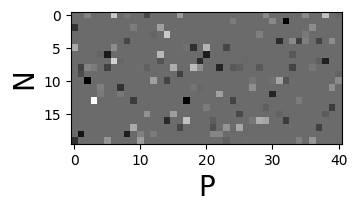

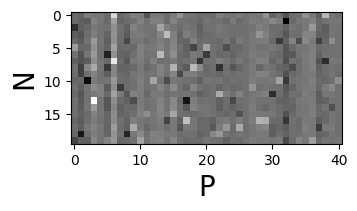

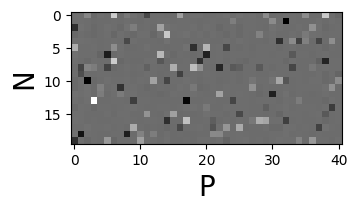

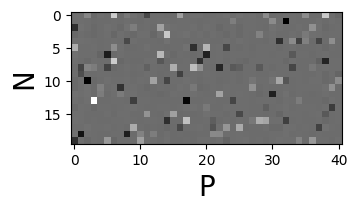

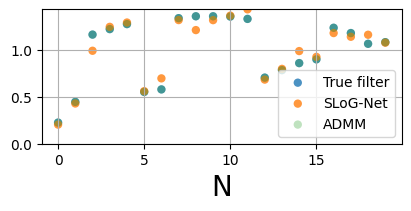

In [ ]:
n_model = 0
n_realiz = 0
P_max = 41
print(result_exp_rex_slog[:,n_model,n_realiz])
print(result_exp_rex_admm[:,n_model,n_realiz])
X0_0 = visual_X0_0[:,:P_max,n_model,n_realiz]
Y_0 = visual_Y_0[:,:P_max,n_model,n_realiz]
g0_0 = visual_g0_0[:,n_model,n_realiz]
X_slog_0 = visual_X_slog_0[:,:P_max,n_model,n_realiz]
g_slog_0 = visual_g_slog_0[:,n_model,n_realiz]
X_admm_0 = visual_X_admm_0[:,:P_max,n_model,n_realiz]
g_admm_0 = visual_g_admm_0[:,n_model,n_realiz]

X0_max = visual_X0_max[:,:P_max,n_model,n_realiz]
Y_max = visual_Y_max[:,:P_max,n_model,n_realiz]
g0_max = visual_g0_max[:,n_model,n_realiz]
X_slog_max = visual_X_slog_max[:,:P_max,n_model,n_realiz]
g_slog_max = visual_g_slog_max[:,n_model,n_realiz]
X_admm_max = visual_X_admm_max[:,:P_max,n_model,n_realiz]
g_admm_max = visual_g_admm_max[:,n_model,n_realiz]

X0, Y, X_slog, X_admm, g0, tag = X0_0, Y_0,  X_slog_0, X_admm_0, g0_0, '0'
# X0, Y, X_slog, X_admm, g0, tag = X0_max, Y_max, X_slog_max, X_admm_max, g0_max, 'max'
fig1, axes = plt.subplots(nrows=1, ncols=1, constrained_layout=True,figsize=(4,2))
plt1 = axes.imshow(X0,cmap='gray')
# axes.set_title('X0')
axes.set_ylabel('N', fontsize = label_fontsize)
axes.set_xlabel('P', fontsize = label_fontsize)
save_name = 'fig_X' + tag + '.pdf'
fig1.savefig(save_name, format="pdf",transparent=True)

fig2, axes = plt.subplots(nrows=1, ncols=1, constrained_layout=True,figsize=(4,2))
plt2 = axes.imshow(Y,cmap='gray')
# axes.set_title('Y')
axes.set_ylabel('N', fontsize = label_fontsize)
axes.set_xlabel('P', fontsize = label_fontsize)
save_name = 'fig_Y' + tag + '.pdf'
fig2.savefig(save_name, format="pdf",transparent=True)

fig3, axes = plt.subplots(nrows=1, ncols=1, constrained_layout=True,figsize=(4,2))
plt3 = axes.imshow(X_slog_0,cmap='gray')
# axes.set_title('X(SLoG)')
axes.set_ylabel('N', fontsize = label_fontsize)
axes.set_xlabel('P', fontsize = label_fontsize)
save_name = 'fig_X_slog_' + tag + '.pdf'
fig3.savefig(save_name, format="pdf",transparent=True)

fig4, axes = plt.subplots(nrows=1, ncols=1, constrained_layout=True,figsize=(4,2))
plt4 = axes.imshow(X_slog_0,cmap='gray')
# axes.set_title('X(ADMM)')
axes.set_ylabel('N', fontsize = label_fontsize)
axes.set_xlabel('P', fontsize = label_fontsize)
save_name = 'fig_X_admm_' + tag + '.pdf'
fig4.savefig(save_name, format="pdf",transparent=True)

fig5, axes = plt.subplots(nrows=1, ncols=1, constrained_layout=True,figsize=(4,2))
axes.scatter([i for i in range(nNodes)], g0, label='True filter', alpha=0.8, linewidth=line_wid, edgecolors='none')
axes.scatter([i for i in range(nNodes)], g_slog_0, label='SLoG-Net', alpha=0.8, linewidth=line_wid, edgecolors='none')
axes.scatter([i for i in range(nNodes)], g_admm_0, label='ADMM', alpha=0.3, linewidth=line_wid, edgecolors='none')
axes.set_ylim([0, max([max(g0), max(g_slog_0), max(g_admm_0)])])
# axes.set_ylabel('N')
axes.set_xlabel('N', fontsize = label_fontsize)
axes.legend()
axes.grid(True)
save_name = 'fig_g_compare_' + tag + '.pdf'
fig5.savefig(save_name, format="pdf",transparent=True)


plt.show()